[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/luleu96/GenAIinDD_Exercises/blob/work/Exercises/Exercise_1/T1_Representation_Learning.ipynb)   

In [1]:
!git clone https://github.com/luleu96/GenAIinDD_Exercises.git
%cd /content/GenAIinDD_Exercises

fatal: destination path 'GenAIinDD_Exercises' already exists and is not an empty directory.
/content/GenAIinDD_Exercises


In [2]:
 # uncomment when in Colab
 #!pip install torch
 #!pip install torch-geometric
!pip install rdkit


In [1]:
import numpy as np
import seaborn as sns
import pandas as pd
import torch

from matplotlib import pyplot as plt
from scipy import stats
from rdkit import Chem
from rdkit.Chem import rdFingerprintGenerator
from rdkit.Chem.Scaffolds import MurckoScaffold
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA


In [2]:
# Additional functions that can be needed:

def scaffold_split(ms, activities, test_size=0.2, random_state=42):
    # Generate scaffolds for each molecule
    scaffolds = [MurckoScaffold.GetScaffoldForMol(m) for m in ms]

    # Create a dictionary to map each scaffold to a list of indices
    scaffold_dict = {}
    for idx, scaffold in enumerate(scaffolds):
        scaffold_smiles = Chem.MolToSmiles(scaffold)
        if scaffold_smiles not in scaffold_dict:
            scaffold_dict[scaffold_smiles] = []
        scaffold_dict[scaffold_smiles].append(idx)

    # Create train and test sets based on scaffold
    train_idx, test_idx = [], []
    scaffold_group = []  # List to track which scaffold group each molecule belongs to

    for scaffold, indices in scaffold_dict.items():
        if len(indices) > 1:
            # Perform train/test split only if there are more than 1 molecule in the scaffold group
            train, test = train_test_split(indices, test_size=test_size, random_state=random_state)
            train_idx.extend(train)
            test_idx.extend(test)
            # Add group number for scaffold (optional)
            scaffold_group.extend([scaffold] * len(indices))
        else:
            # If there is only one molecule in this scaffold group, assign it to the train set
            train_idx.append(indices[0])
            scaffold_group.append(scaffold)

    # Return the corresponding molecules and activities for train and test sets
    X_train, X_test = np.array(ms)[train_idx], np.array(ms)[test_idx]
    y_train, y_test = activities[train_idx], activities[test_idx]

    # Return train and test indices and scaffold group information
    return X_train, X_test, y_train, y_test, train_idx, test_idx, scaffold_group

def calculate_regression_metrics(predictions, targets):
    """
    Calculate regression metrics including MAE, MSE, R², Pearson's r, and Spearman's rank correlation.

    Args:
        predictions (torch.Tensor): Model's predicted values (output of model).
        targets (torch.Tensor): True target values (ground truth).

    Returns:
        dict: A dictionary containing various regression metrics.
    """
    # Ensure predictions and targets are the same shape
    assert predictions.shape == targets.shape, "Predictions and targets must have the same shape"

    # Convert tensors to numpy arrays for easier computation
    predictions = predictions.detach().cpu().numpy().ravel()
    targets = targets.detach().cpu().numpy().ravel()

    # Calculate Mean Absolute Error (MAE)
    mae = np.mean(np.abs(predictions - targets))

    # Calculate Mean Squared Error (MSE)
    mse = np.mean((predictions - targets) ** 2)

    # Calculate R-squared (R²)
    ss_total = np.sum((targets - np.mean(targets)) ** 2)
    ss_residual = np.sum((targets - predictions) ** 2)
    r_squared = 1 - (ss_residual / ss_total)

    # Calculate Pearson correlation coefficient (r)
    pearson_corr, _ = stats.pearsonr(predictions, targets)

    # Calculate Spearman rank correlation coefficient (rho)
    spearman_corr, _ = stats.spearmanr(predictions, targets)

    # Return a dictionary of the metrics
    return {
        'MAE': mae,
        'MSE': mse,
        'R_squared': r_squared,
        'Pearson_r': pearson_corr,
        'Spearman_rho': spearman_corr
    }

class LinearRegressionModel(torch.nn.Module):
    def __init__(self, input_dim):
        super(LinearRegressionModel, self).__init__()
        self.linear = torch.nn.Linear(input_dim, 1)  # Simple linear layer (input -> output)

    def forward(self, x):
        return self.linear(x)


class DeepNeuralNetworkModel(torch.nn.Module):
    def __init__(self, input_dim, hidden_dim=16, num_hidden_layers=2):
        super(DeepNeuralNetworkModel, self).__init__()

        # Input layer
        self.input_layer = torch.nn.Sequential(
            torch.nn.Linear(input_dim, hidden_dim),
            torch.nn.ReLU()
        )

        # Hidden layers: each has Linear + ReLU
        self.hidden_layers = torch.nn.ModuleList([
            torch.nn.Sequential(torch.nn.Linear(hidden_dim, hidden_dim), torch.nn.ReLU())
            for _ in range(num_hidden_layers - 1)
        ])

        # Output layer
        self.output_layer = torch.nn.Linear(hidden_dim, 1)
        
    
    def forward(self, x):
        hidden_states = []  # List to store outputs from each layer
        
        # Input layer
        x = self.input_layer(x)
        hidden_states.append(x)  # Save output
        
        # Hidden layers
        for layer in self.hidden_layers:
            x = layer(x)
            hidden_states.append(x)  # Save output

        # Output layer
        x = self.output_layer(x)
        return x, hidden_states  # Return final output and intermediate states
    

def train_model(train_features, train_values, test_features, test_values,
                criterion, optimizer, model_name, model, epochs=1500, patience=200):

    # Initialize lists to store the loss values and activations
    train_losses = []
    test_losses = []
    all_activations = []  # List to store activations for t-SNE or other analysis

    # Early stopping settings
    best_test_loss = float('inf')  # Initialize to a very large value
    epochs_without_improvement = 0  # Counter to track epochs without improvement

    for epoch in range(epochs):
        model.train()  # Set model to training mode

        # Forward pass on training data
        pred_train_values, activations_train = model(train_features)  # Unpack tuple
        loss = criterion(pred_train_values, train_values)

        # Capture activations for t-SNE or analysis
        all_activations.append(activations_train)  # Store activations from all layers

        # Backward pass and optimization
        optimizer.zero_grad()  # Clear gradients
        loss.backward()  # Compute gradients
        optimizer.step()  # Update model parameters

        # Validation phase (no gradients)
        model.eval()  # Set model to evaluation mode

        with torch.no_grad():  # No gradients required for evaluation
            pred_test_values, _ = model(test_features)  # Unpack final predictions only
            test_loss = criterion(pred_test_values, test_values)  # Compute validation loss

            # Calculate additional metrics
            metrics = calculate_regression_metrics(pred_test_values, test_values)

        # Store the loss values
        train_losses.append(loss.item())  # Append training loss to list
        test_losses.append(test_loss.item())  # Append test loss to list

        # Check if the model has improved on the validation loss
        if test_loss < best_test_loss:
            best_test_loss = test_loss  # Update the best validation loss
            epochs_without_improvement = 0  # Reset counter
            torch.save(model.state_dict(), f'best_{model_name}.pth')  # Save the model checkpoint (only when it improves)
        else:
            epochs_without_improvement += 1

        # Early stopping: if no improvement for 'patience' epochs, stop training
        if epochs_without_improvement >= patience:
            print(f"Early stopping at epoch {epoch+1} due to no improvement.")
            break

        # Print training and validation losses periodically
        if epoch % 100 == 0:
            print(f'Epoch [{epoch+1:4d}/{epochs:4d}], '  # Pad with spaces to align digits
                  f'Train Loss: {loss.item():.4f}, '
                  f'Test Loss: {test_loss.item():.4f}, '
                  f'MAE: {metrics["MAE"]:.4f}, '
                  f'MSE: {metrics["MSE"]:.4f}, '
                  f'R²: {metrics["R_squared"]:.4f}, '
                  f'Pearson r: {metrics["Pearson_r"]:.4f}, '
                  f'Spearman rho: {metrics["Spearman_rho"]:.4f}')

    # Return activations, losses, and final predictions
    return pred_test_values, train_losses, test_losses, all_activations


# Start here

In [7]:
import os
working_dir = os.getcwd()
print(working_dir)

/content/GenAIinDD_Exercises


In [8]:
# Step 1: Read molecules in SMILES format

In [ ]:
#data = pd.read_csv(os.path.join(working_dir, "Data", "egfr_pIC50_tutorial.csv"))
#data = pd.read_csv("c:\\Users\\opalomin\\Documents\\GenAIinDD_Exercises\\Data\\egfr_pIC50_tutorial.csv")
data = pd.read_csv('/content/GenAIinDD_Exercises/Data/egfr_pIC50.csv')

mol_col = "MOL_smiles"
data_col = "pIC50"

print("Shape of dataframe : ", data.shape)
data.head(5)

Shape of dataframe :  (4396, 4)


,MOL_smiles,pIC50,Gene_Symbol,Original_Entry_ID
0,CCOc1cc2ncc(C#N)c(Nc3ccc(OCc4nc5ccccc5s4)c(Cl)...,6.73,EGFR,CHEMBL175513
1,O=C1NC(=O)c2cc(Nc3ccccc3)c(Nc3ccccc3)cc21,6.80,EGFR,CHEMBL268868
2,CC(=O)NCCn1ccc2ncnc(Nc3ccc(Oc4cccc5sncc45)c(Cl...,8.54,EGFR,CHEMBL2048906
3,CCOc1ccc(-c2nn(C3CCCC3)c3ncnc(N)c23)cc1OC,5.85,EGFR,CHEMBL1240554
4,C#Cc1cccc(Nc2ncnc3cc(OCCOC)c(OCCOC)cc23)c1,9.70,EGFR,CHEMBL553


In [10]:
# Step 2: Visualize dataset

(1, 5000)

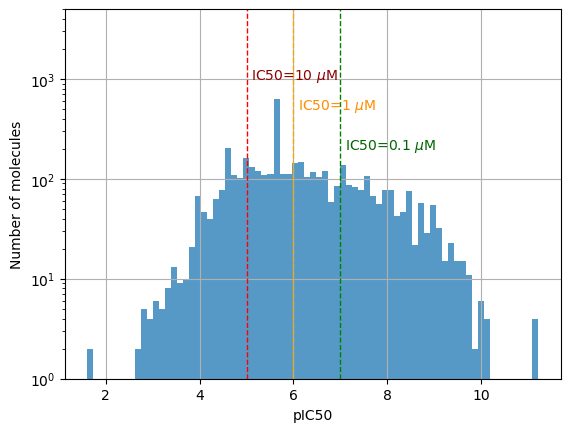

In [9]:
fig = data[data_col].hist(bins=75,alpha=0.75)
plt.xlabel("pIC50")
plt.ylabel("Number of molecules")

fig.axvline(5, color="red", linestyle="dashed", linewidth=1)
fig.annotate(r"IC50=10 $\mu$M ", xy=(3, 350), xytext=(5.1, 1000), color="darkred")

fig.axvline(6, color="orange", linestyle="dashed", linewidth=1)
fig.annotate(r"IC50=1 $\mu$M", xy=(6, 450), xytext=(6.1, 500), color="darkorange")

fig.axvline(7, color="green", linestyle="dashed", linewidth=1)
fig.annotate(r"IC50=0.1 $\mu$M ", xy=(7, 500), xytext=(7.1, 200), color="darkgreen")

plt.yscale("log")
plt.ylim(1,5000)

In [12]:
# Step 3: Generate features from the dataset

In [4]:
## Get Features
ms = [Chem.MolFromSmiles(m) for m in data[mol_col].values]
fpgen = rdFingerprintGenerator.GetMorganGenerator(radius=2, fpSize=2048)
features = np.array([fpgen.GetFingerprintAsNumPy(m) for m in ms])

print(features.shape)
print(features)
print('')

## Get the Inhibition values
activities = data[data_col].values
print(activities.shape)
print(activities)

(4396, 2048)
[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]

(4396,)
[6.73 6.8  8.54 ... 6.21 6.25 5.8 ]


In [33]:
#data point 0
features[0]

array([0, 0, 0, ..., 0, 0, 0], dtype=uint8)

In [5]:
np.sum(features[0])

83

#### Computing the Singular Value Decomposition (SVD) of a Matrix A
Given a matrix $A$  we need decompose it into the Matrices $ U $, $ \Sigma $, and $ V $. For this, we need to follow the next steps:
1. Compute the square matrices  $A^T A$ and  $A A^T$ 
2. Obtain the singular values for $ \Sigma $ from the singular values of $A^T A$
3. The right singular vectors are the columns of the matrix $ V $, which are the eigenvectors of the matrix $A^T A$ 
4. The right singular vectors are the columns of the matrix $ U $, which are the eigenvectors of the matrix $A A^T$ 

A working example can be found here: https://www.d.umn.edu/~mhampton/m4326svd_example.pdf


In [ ]:
### SVD
U, S, Vt = np.linalg.svd(features, full_matrices=True)

In [15]:
print(U.shape)
print(U)

# The columns of $U$ represent the directions in the sample space that explain the variance in your data. Each column shows how strongly each data point is aligned with each principal component.
# The first column of U shows how the samples (data points) relate to the first principal component (most important direction), and so on...

(4396, 4396)
[[-2.17170249e-02 -6.50389577e-04  5.16883739e-02 ... -4.38167784e-03
  -1.19486728e-02 -1.51329674e-02]
 [-9.30740717e-03  7.58262853e-03  5.02177597e-03 ... -5.25966027e-03
   5.77622698e-03  8.36157646e-03]
 [-2.13741862e-02 -1.10680637e-02  6.80577107e-03 ... -1.19633323e-02
   4.03309281e-03  2.12623299e-02]
 ...
 [-1.04928872e-02  1.94125752e-02  1.94561888e-02 ...  8.04518535e-01
  -2.34271957e-03 -5.80103648e-03]
 [-1.17016316e-02  2.53757535e-02  7.06626470e-03 ...  2.09819387e-03
   4.98034891e-01 -2.13128858e-03]
 [-8.00820731e-03  1.01422620e-02 -5.69106143e-04 ... -3.55246926e-04
  -1.01696530e-03  1.60376588e-01]]


In [16]:
print(S.shape)
print(S)

(2048,)
[2.44838909e+02 9.50930549e+01 7.50452152e+01 ... 2.29869050e-15
 7.92828076e-16 5.86407555e-17]


In [17]:
print(Vt.shape)
print(Vt)

#The rows of $V^T$  (or equivalently, the columns of $V$) represent the directions in the feature space (the original feature space) that explain the variance in your data.
# The first row of $V^T$ (or column of V) tells you which features are most important for the first principal component, the second row for the second component, and so on. It tells you what the principal components are in terms of the original features.

(2048, 2048)
[[-5.68806472e-05 -2.69127466e-02 -4.02525302e-03 ... -9.01278116e-04
  -7.97396467e-03 -1.32058634e-03]
 [ 2.72966428e-04  4.48807602e-02  4.24822915e-03 ...  1.66653623e-03
  -1.71226962e-03  2.49636138e-03]
 [-4.34295417e-05 -4.28182061e-02  3.32148303e-03 ...  5.10775605e-04
  -1.48818064e-02 -2.00550172e-03]
 ...
 [ 0.00000000e+00 -1.44746126e-16  4.03175826e-17 ... -2.32816010e-17
  -7.71051712e-17 -3.02108991e-16]
 [ 0.00000000e+00 -1.86636488e-17 -8.47211679e-18 ...  8.75416185e-18
  -2.49164172e-17  3.68733662e-17]
 [ 0.00000000e+00 -1.16103679e-16 -2.96516504e-17 ... -5.39083692e-17
  -7.34701808e-17  6.79985058e-17]]


In [18]:
k = 2  # Choose the number of principal components
Vt_k = Vt[:k, :]  # Get the first k rows of Vt (top k principal components)
reduced_features = np.dot(features, Vt_k.T)  # Project the original data onto the reduced space

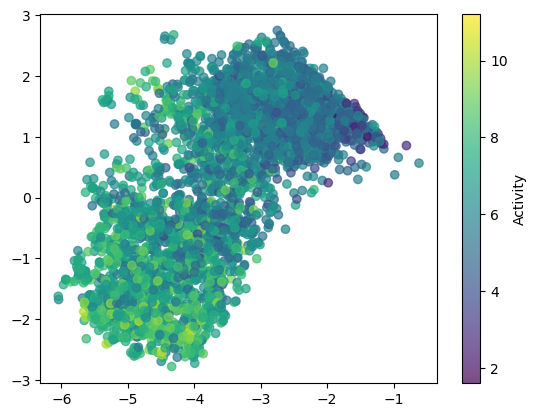

In [19]:
scatter = plt.scatter(reduced_features[:, 0], reduced_features[:, 1], c=activities, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Activity")  # Optional: color bar to indicate activity levels


If you don't reduce the dimensionality and simply use the full $V^T$ (i.e., use all of the $n$ components), you're not really performing dimensionality reduction but rather just rotating the feature space. So yes, this creates a new representation of your features, but it won't necessarily help in situations where you want to reduce noise or find a lower-dimensional structure in the data.

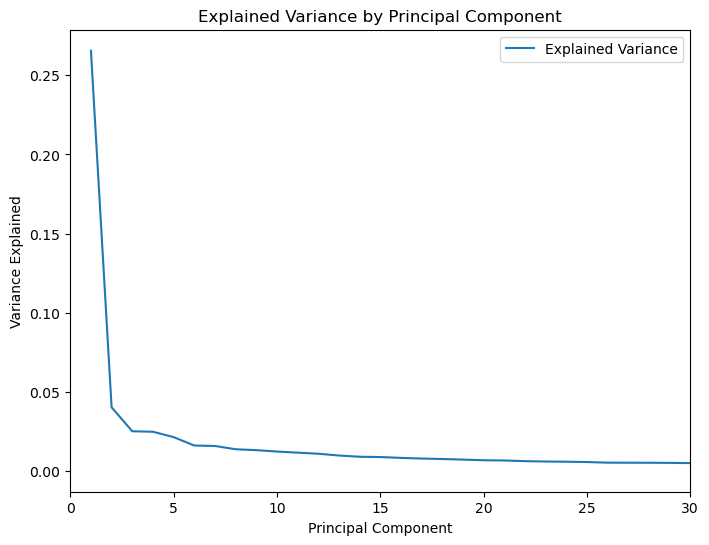

In [22]:
#Is 2 dimensions enough?

# Calculate the explained variance ratio for each component
explained_variance_ratio = (S ** 2) / np.sum(S ** 2)

# Calculate the cumulative explained variance
cumulative_variance = np.cumsum(explained_variance_ratio)

# Plot the explained variance and cumulative explained variance
plt.figure(figsize=(8, 6))
plt.plot(np.arange(1, len(S) + 1), explained_variance_ratio, label='Explained Variance')
#plt.plot(np.arange(1, len(S) + 1), cumulative_variance, label='Cumulative Explained Variance', linestyle='--')
plt.xlabel('Principal Component')
plt.xlim(0,30)
plt.ylabel('Variance Explained')
plt.title('Explained Variance by Principal Component')
plt.legend()
plt.show()


t-SNE is a machine learning algorithm primarily used for dimensionality reduction and data visualization. It can embed high-dimensional data into 2 or 3 dimensions, normally. The key feature of t-SNE is that it aims to preserve the **local structure** of the data while **projecting it** into a lower-dimensional space, typically 2D or 3D, for better interpretation.

#### How t-SNE Works

 1. Measure Pairwise Similarities in High-Dimensional Space: t-SNE starts by calculating the similarity between data points in the high-dimensional space. The goal is to ensure that points that are close to each other in the original space remain close in the lower-dimensional representation, and points that are far apart should remain distant.
$$
P_{ij} = \frac{\exp\left(-\frac{\| x_i - x_j \|^2}{2 \sigma_i^2}\right)}{\sum_{k \neq i} \exp\left(-\frac{\| x_i - x_k \|^2}{2 \sigma_i^2}\right)}
$$
Where $ \sigma_i $ is the bandwidth (or "perplexity" parameter) of the Gaussian distribution around point $ x_i $. The **perplexity** can be thought of as a parameter that controls the balance between local and global data relationships (typically between 5 and 50).

2. Construct a Probability Distribution in High-Dimensional Space: For each data point $ x_i $, we calculate the probability that $ x_j $ would be a neighbor of $ x_i $, which is the normalized similarity $ P_{ij} $. This results in a joint probability distribution $ P = \{ P_{ij} \} $ over pairs of points in the high-dimensional space. The probabilities are symmetric, meaning $ P_{ij} = P_{ji} $.

3. Embed the Data in a Lower-Dimensional Space: Next, t-SNE initializes a random low-dimensional configuration for the data points (often 2D or 3D). The goal is to find a lower-dimensional representation of the data, say $ y_i $ for each data point $ x_i $, where the probability distribution of the points in the lower-dimensional space matches the one from the high-dimensional space.

In this lower-dimensional space, t-SNE uses a **Student's t-distribution** (instead of a Gaussian) to measure the similarities between points. The similarity between points \$y_i $ and $ y_j $ in the low-dimensional space is computed as:

$$
Q_{ij} = \frac{(1 + \| y_i - y_j \|^2)^{-1}}{\sum_{k \neq i} (1 + \| y_i - y_k \|^2)^{-1}}
$$

4. Minimize the Divergence Between the Two Distributions
The key idea is to minimize the difference (or divergence) between the high-dimensional probability distribution $ P $ and the low-dimensional probability distribution $ Q $. This is typically done using **Kullback-Leibler divergence** (KL-divergence), which measures the "distance" between two probability distributions:

$$
\text{KL}(P \parallel Q) = \sum_{i \neq j} P_{ij} \log \frac{P_{ij}}{Q_{ij}}
$$

The algorithm seeks to adjust the low-dimensional positions $ y_i $ to minimize this KL-divergence, effectively ensuring that pairs of points that were similar in the high-dimensional space remain similar in the low-dimensional representation.




#### Key Features of t-SNE

1. **Preserves Local Structure**: t-SNE focuses on preserving local relationships, meaning it tries to keep nearby points (in high-dimensional space) close together in the low-dimensional space. This works especially when clusters or patterns are not obvious in high-dimensional space.
2. **Non-linear**: t-SNE can capture complex, non-linear relationships between data points.

#### Disadvantages of t-SNE

- **Computationally Expensive**: t-SNE can be slow, especially for large datasets, because it requires calculating pairwise similarities and performing iterative optimization.
- **Hard to Interpret**: Unlike linear methods, which provides a linear projection with clear relationships between the original dimensions and the reduced dimensions, t-SNE provides a non-linear transformation, making it harder to interpret the meaning of the axes.
- **Perplexity and Initialization**: The results can vary based on the choice of hyperparameters like perplexity and the initial random placement of points, so it might need some tuning.



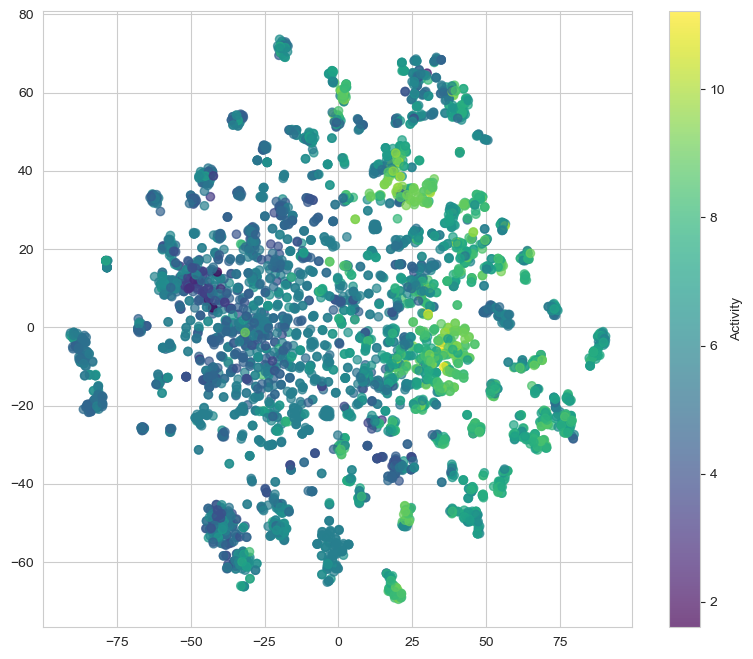

In [ ]:
# Othe embedding techniques
tsne = TSNE(n_components=2, perplexity=30, random_state=42, n_jobs=1).fit_transform(features)

plt.figure(figsize=(9.5, 8))
sns.set_style("whitegrid")

### Color by activity (for regression, you can use a continuous color scale)
scatter = plt.scatter(tsne[:, 0], tsne[:, 1], c=activities, cmap='viridis', alpha=0.7)
plt.colorbar(scatter, label="Activity")  # Optional: color bar to indicate activity levels

In [ ]:
# Step 5: Split data in train and test datasets

In [9]:
X_train, X_test, y_train, y_test, train_idx, test_idx, scaffold_group = scaffold_split(ms, activities, test_size=0.3)

train_features = torch.tensor(np.array([fpgen.GetFingerprintAsNumPy(m) for m in X_train]), dtype=torch.float32)
test_features = torch.tensor(np.array([fpgen.GetFingerprintAsNumPy(m) for m in X_test]), dtype=torch.float32)

train_values = torch.tensor(y_train, dtype=torch.float32).view(-1, 1)
test_values = torch.tensor(y_test, dtype=torch.float32).view(-1, 1)


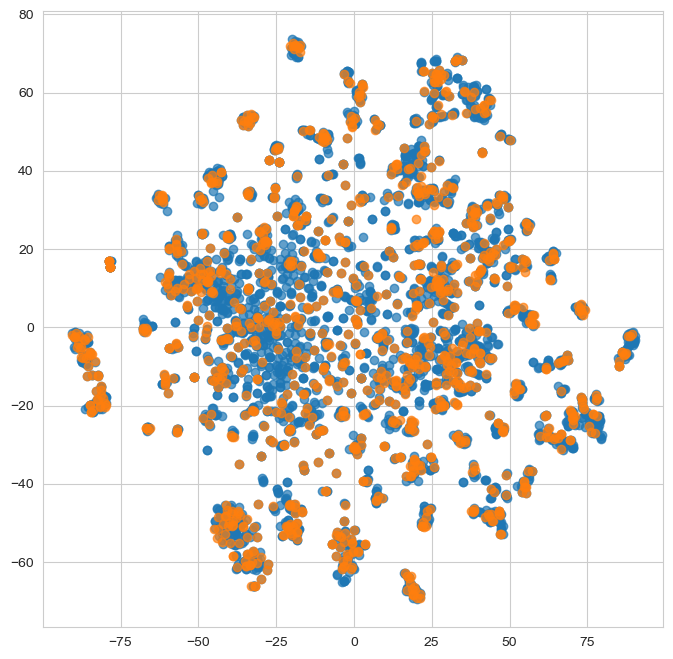

In [16]:
plt.figure(figsize=(8, 8))
sns.set_style("whitegrid")

### Color by split
scatter = plt.scatter(tsne[train_idx, 0], tsne[train_idx, 1], alpha=0.7)
scatter = plt.scatter(tsne[test_idx, 0], tsne[test_idx, 1], alpha=0.7)


In [89]:
input_dim = train_features.shape[1]  # Number of features (fingerprint length)
model = DeepNeuralNetworkModel(input_dim)
criterion = torch.nn.MSELoss()  # Mean Squared Error for regression
optimizer = torch.optim.Adam(model.parameters(), lr=0.001)

training_args = {
    "train_features" : train_features,
    "train_values" : train_values,
    "criterion" : criterion,
    "optimizer" : optimizer,
    "test_features" : test_features,
    "test_values" : test_values,
    "model_name" : "linear",
    "model":model,
    "epochs" : 200,
    "patience" : 200
}

pred_test_values, train_losses, test_losses, all_activations = train_model(**training_args)

Epoch [   1/ 200], Train Loss: 38.3753, Test Loss: 37.7354, MAE: 5.9908, MSE: 37.7354, R²: -19.4044, Pearson r: 0.2405, Spearman rho: 0.2452
Epoch [ 101/ 200], Train Loss: 2.3893, Test Loss: 2.2313, MAE: 1.1552, MSE: 2.2313, R²: -0.2065, Pearson r: 0.4086, Spearman rho: 0.4156


In [11]:
# Before training a neural network

In [ ]:
# Takes 1:30 mins
# Convert hidden states to numpy and flatten for visualization
input_features     = train_features.detach().numpy()
hidden_states_1_np = all_activations[0][0].detach().numpy()
hidden_states_2_np = all_activations[0][1].detach().numpy()

# Apply t-SNE to each layer's output
input_layer_tsne     = TSNE(n_components=2, random_state=42).fit_transform(input_features)
hidden_states_1_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_1_np)
hidden_states_2_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_2_np)

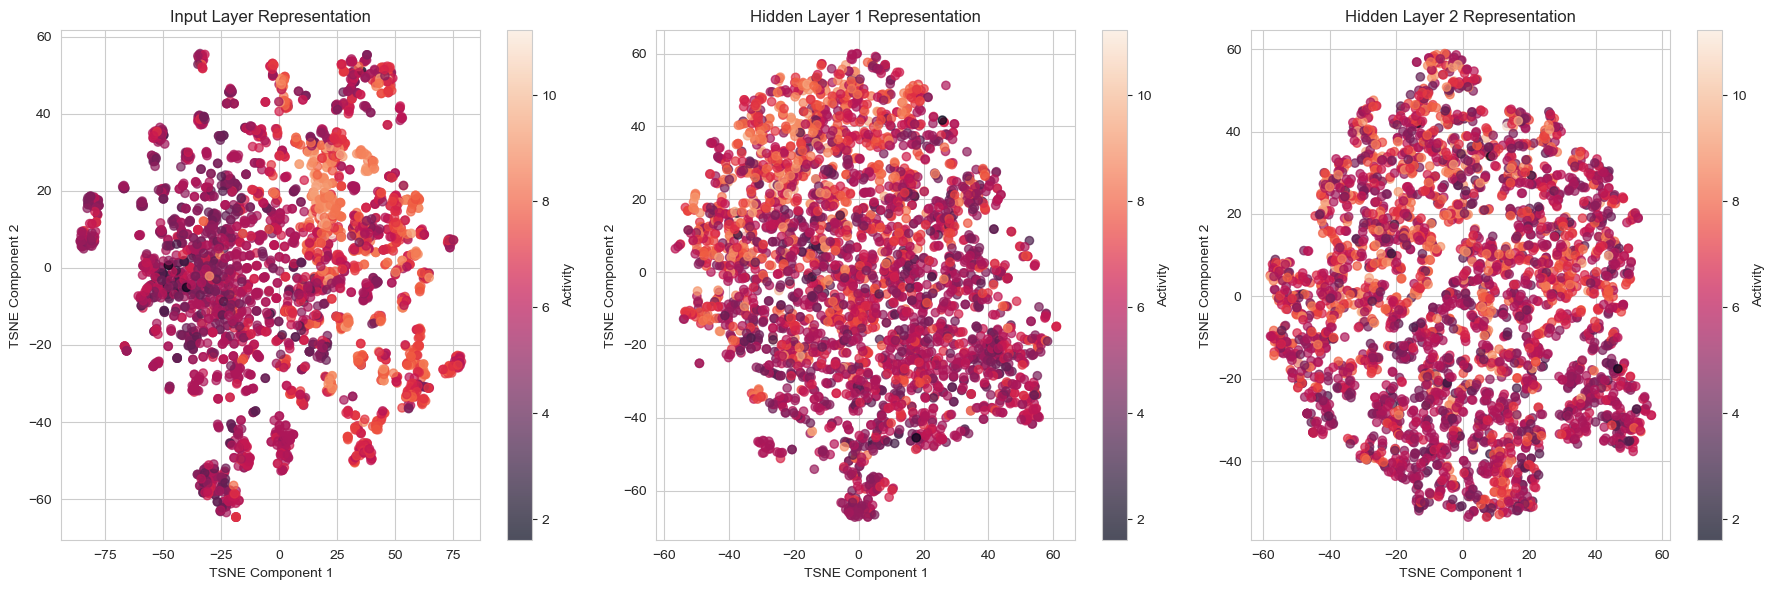

In [94]:

# Create subplots for the three t-SNE results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot t-SNE for the input layer
scatter1 = axs[0].scatter(input_layer_tsne[:, 0], input_layer_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[0].set_title("Input Layer Representation")
axs[0].set_xlabel("TSNE Component 1")
axs[0].set_ylabel("TSNE Component 2")
plt.colorbar(scatter1, ax=axs[0], label="Activity")  # Add color bar to first axis

# Plot t-SNE for the first hidden layer
scatter2 = axs[1].scatter(hidden_states_1_tsne[:, 0], hidden_states_1_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[1].set_title("Hidden Layer 1 Representation")
axs[1].set_xlabel("TSNE Component 1")
axs[1].set_ylabel("TSNE Component 2")
plt.colorbar(scatter2, ax=axs[1], label="Activity")  # Add color bar to second axis

# Plot t-SNE for the second hidden layer
scatter3 = axs[2].scatter(hidden_states_2_tsne[:, 0], hidden_states_2_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[2].set_title("Hidden Layer 2 Representation")
axs[2].set_xlabel("TSNE Component 1")
axs[2].set_ylabel("TSNE Component 2")
plt.colorbar(scatter3, ax=axs[2], label="Activity")  # Add color bar to third axis

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Around half trained neural network

In [96]:
# Takes 1:30 mins
# Convert hidden states to numpy and flatten for visualization
input_features     = train_features.detach().numpy()
hidden_states_1_np = all_activations[99][0].detach().numpy()
hidden_states_2_np = all_activations[99][1].detach().numpy()

# Apply t-SNE to each layer's output
input_layer_tsne     = TSNE(n_components=2, random_state=42).fit_transform(input_features)
hidden_states_1_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_1_np)
hidden_states_2_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_2_np)

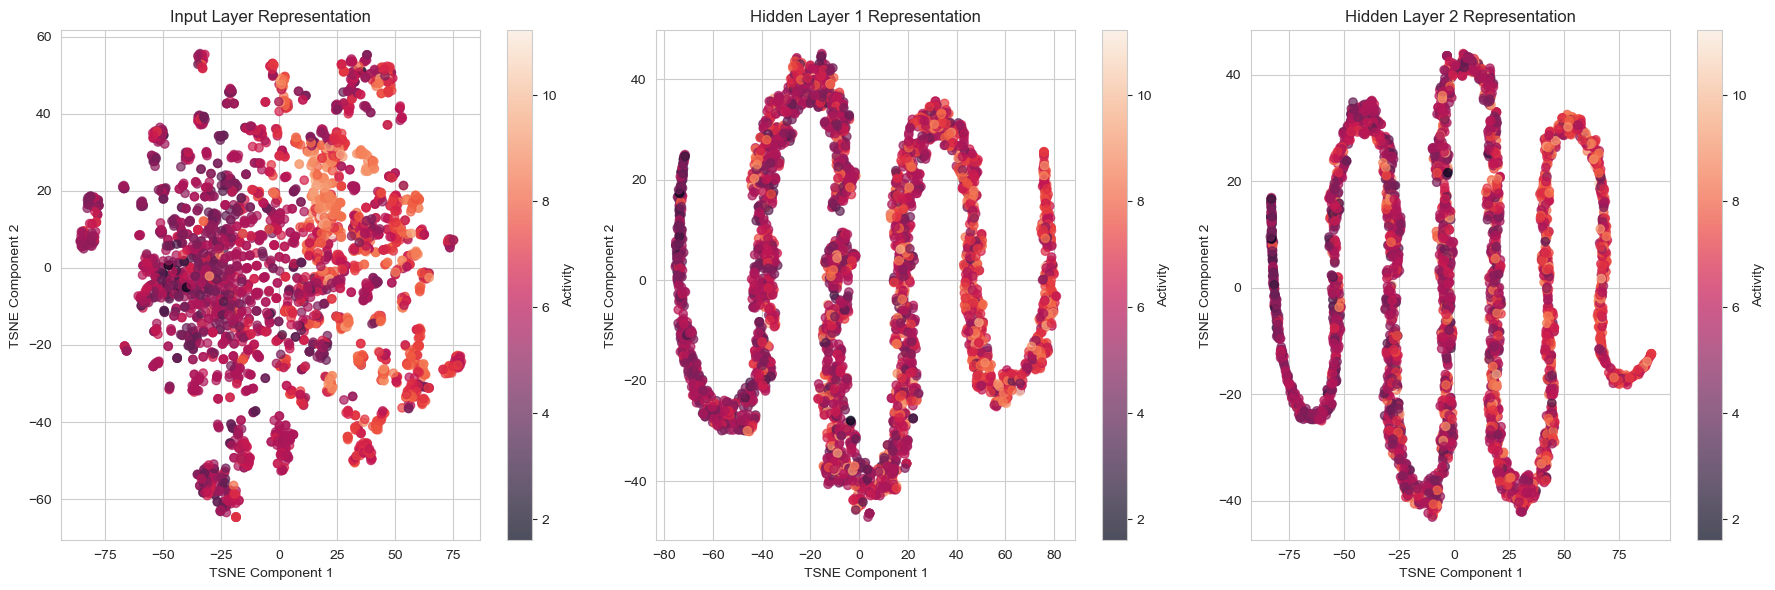

In [97]:

# Create subplots for the three t-SNE results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot t-SNE for the input layer
scatter1 = axs[0].scatter(input_layer_tsne[:, 0], input_layer_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[0].set_title("Input Layer Representation")
axs[0].set_xlabel("TSNE Component 1")
axs[0].set_ylabel("TSNE Component 2")
plt.colorbar(scatter1, ax=axs[0], label="Activity")  # Add color bar to first axis

# Plot t-SNE for the first hidden layer
scatter2 = axs[1].scatter(hidden_states_1_tsne[:, 0], hidden_states_1_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[1].set_title("Hidden Layer 1 Representation")
axs[1].set_xlabel("TSNE Component 1")
axs[1].set_ylabel("TSNE Component 2")
plt.colorbar(scatter2, ax=axs[1], label="Activity")  # Add color bar to second axis

# Plot t-SNE for the second hidden layer
scatter3 = axs[2].scatter(hidden_states_2_tsne[:, 0], hidden_states_2_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[2].set_title("Hidden Layer 2 Representation")
axs[2].set_xlabel("TSNE Component 1")
axs[2].set_ylabel("TSNE Component 2")
plt.colorbar(scatter3, ax=axs[2], label="Activity")  # Add color bar to third axis

# Adjust layout for better spacing
plt.tight_layout()
plt.show()

In [ ]:
# Fully trained neural network

In [98]:
# Takes 1:30 mins
# Convert hidden states to numpy and flatten for visualization
input_features     = train_features.detach().numpy()
hidden_states_1_np = all_activations[199][0].detach().numpy()
hidden_states_2_np = all_activations[199][1].detach().numpy()

# Apply t-SNE to each layer's output
input_layer_tsne     = TSNE(n_components=2, random_state=42).fit_transform(input_features)
hidden_states_1_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_1_np)
hidden_states_2_tsne = TSNE(n_components=2, random_state=42).fit_transform(hidden_states_2_np)

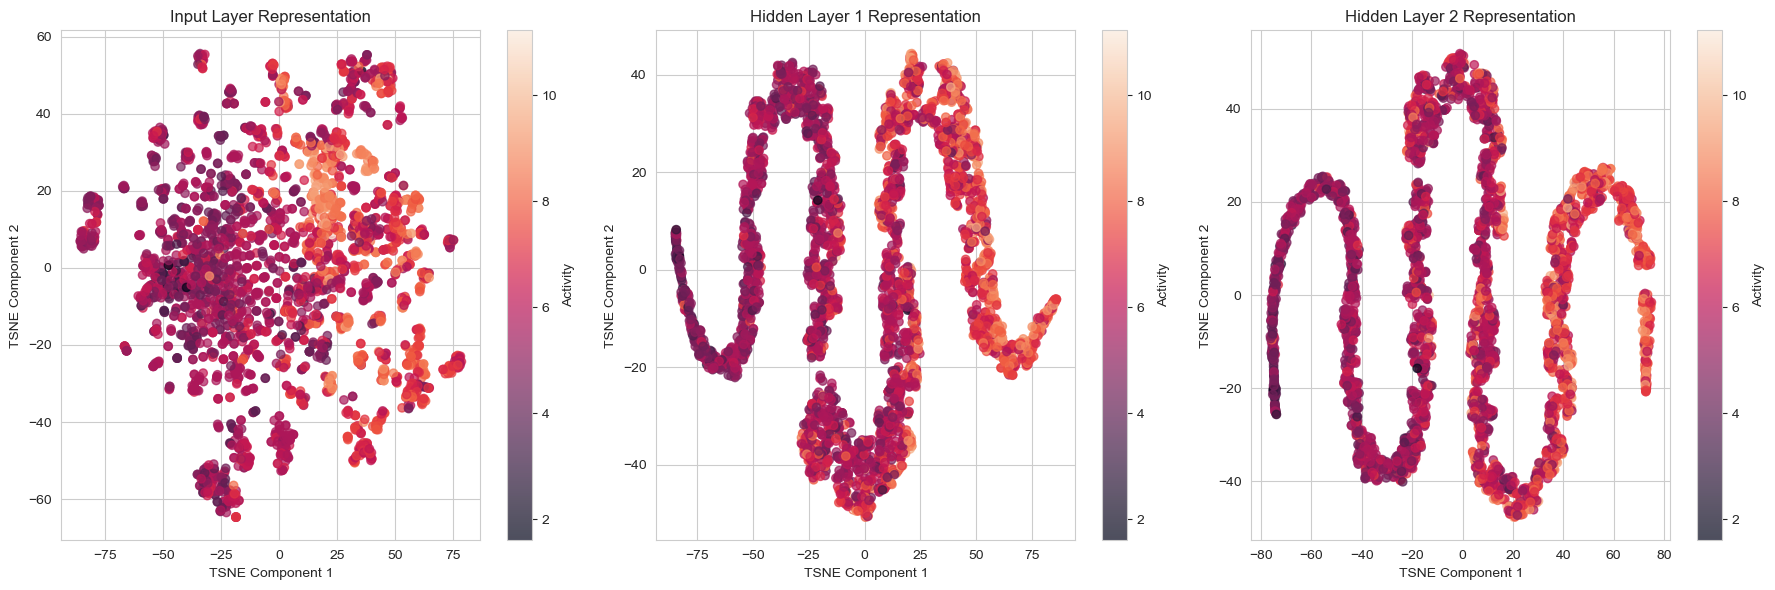

In [99]:

# Create subplots for the three t-SNE results
fig, axs = plt.subplots(1, 3, figsize=(18, 6))

# Plot t-SNE for the input layer
scatter1 = axs[0].scatter(input_layer_tsne[:, 0], input_layer_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[0].set_title("Input Layer Representation")
axs[0].set_xlabel("TSNE Component 1")
axs[0].set_ylabel("TSNE Component 2")
plt.colorbar(scatter1, ax=axs[0], label="Activity")  # Add color bar to first axis

# Plot t-SNE for the first hidden layer
scatter2 = axs[1].scatter(hidden_states_1_tsne[:, 0], hidden_states_1_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[1].set_title("Hidden Layer 1 Representation")
axs[1].set_xlabel("TSNE Component 1")
axs[1].set_ylabel("TSNE Component 2")
plt.colorbar(scatter2, ax=axs[1], label="Activity")  # Add color bar to second axis

# Plot t-SNE for the second hidden layer
scatter3 = axs[2].scatter(hidden_states_2_tsne[:, 0], hidden_states_2_tsne[:, 1], c=activities[train_idx], alpha=0.7)
axs[2].set_title("Hidden Layer 2 Representation")
axs[2].set_xlabel("TSNE Component 1")
axs[2].set_ylabel("TSNE Component 2")
plt.colorbar(scatter3, ax=axs[2], label="Activity")  # Add color bar to third axis

# Adjust layout for better spacing
plt.tight_layout()
plt.show()